<a href="https://colab.research.google.com/github/ruveydakarakoyun/APTOS-2019/blob/main/aptos_2019.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Veri Yükleme ve Kütüphaneleri Yükleme

In [1]:
from dataset import APTOSDataset

In [2]:
import torch

print("PyTorch Versiyonu:", torch.__version__)
print("Mac M2 GPU (MPS) Kullanılabilir mi?:", torch.backends.mps.is_available())

PyTorch Versiyonu: 2.14.0
Mac M2 GPU (MPS) Kullanılabilir mi?: True


In [3]:
import torch

device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "mps" if torch.backends.mps.is_available()
    else "cpu"
)

print("PyTorch Versiyonu:", torch.__version__)
print("🚀 Aktif Cihaz:", device)

if device.type == "cuda":
    print("GPU Adı:", torch.cuda.get_device_name(0))
elif device.type == "cpu":
    print("⚠️ GPU bulunamadı. Colab'da: Runtime → Change runtime type → Hardware accelerator → GPU seç.")

PyTorch Versiyonu: 2.14.0
🚀 Aktif Cihaz: mps


In [4]:
import torch

# Mac M2 (MPS), Nvidia (CUDA) ve CPU dinamik cihaz ataması
if torch.backends.mps.is_available():
    device = torch.device("mps")
    print("🚀 Aktif Cihaz: Mac M2 Pro GPU (MPS)")
elif torch.cuda.is_available():
    device = torch.device("cuda")
    print(f"🚀 Aktif Cihaz: Nvidia GPU ({torch.cuda.get_device_name(0)})")
else:
    device = torch.device("cpu")
    print("⚠️ Aktif Cihaz: CPU")

🚀 Aktif Cihaz: Mac M2 Pro GPU (MPS)


In [5]:
# ==============================================================================
# 1. GEREKLİ KÜTÜPHANELER
# ==============================================================================
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T

# ==============================================================================
# 2. GPU / DEVICE KONTROLÜ
# ==============================================================================
device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "mps" if torch.backends.mps.is_available()
    else "cpu"
)

print("PyTorch Versiyonu:", torch.__version__)
print("🚀 Aktif Cihaz:", device)

if device.type == "cuda":
    print("GPU Adı:", torch.cuda.get_device_name(0))
elif device.type == "cpu":
    print("⚠️ GPU bulunamadı, CPU ile devam edilecek (eğitim yavaş olabilir).")
    print("Colab'da: Üst menü → Runtime → Change runtime type → Hardware accelerator → GPU seç.")

# ==============================================================================
# 3. GOOGLE DRIVE BAĞLAMA (SADECE COLAB'DA ÇALIŞIR)
# ==============================================================================
try:
    from google.colab import drive
    drive.mount('/content/drive')
    IN_COLAB = True
    print("✅ Google Drive bağlandı.")
except ImportError:
    IN_COLAB = False
    print("ℹ️ Colab ortamı değil, Drive bağlama atlandı.")

# ==============================================================================
# 4. VERİ YOLU AYARLARI
# ==============================================================================
# Kendi Drive klasör yapına göre bu satırı düzenle
DATA_DIR = "/content/drive/MyDrive/aptos2019" if IN_COLAB else "./data"

TRAIN_CSV = os.path.join(DATA_DIR, "train.csv")
TEST_CSV = os.path.join(DATA_DIR, "test.csv")

print("📁 Veri klasörü:", DATA_DIR)

PyTorch Versiyonu: 2.14.0
🚀 Aktif Cihaz: mps
ℹ️ Colab ortamı değil, Drive bağlama atlandı.
📁 Veri klasörü: ./data


In [6]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T

# Yerel Dizin ve Veri Yolları Ayarları
# Verileri Colab veya yerel ortamda sakladığınız klasör yolu
DATA_DIR = "./data"  # Örn: Colab için "/content/aptos" veya yerel yol
TRAIN_CSV = os.path.join(DATA_DIR, "train.csv")
TEST_CSV = os.path.join(DATA_DIR, "test.csv")

print("✅ Kütüphaneler ve yerel çalışma ortamı hazır!")

✅ Kütüphaneler ve yerel çalışma ortamı hazır!


###Tabloları Çekme

In [7]:
import os
import pandas as pd

# ==============================================================================
# OTOMATİK ORTAM ALGILAMA (Kod yapısını ve değişkenleri değiştirmeden)
# ==============================================================================
try:
    import google.colab
    DATA_DIR = "/content/drive/MyDrive/aptos2019"
    print("🚀 Google Colab ortamı algılandı.")
except ImportError:
    # Yerel Mac'te colab yolu olmadığı için klasör adını doğrudan eşliyoruz
    DATA_DIR = "aptos2019"
    print("💻 Yerel Mac ortamı algılandı.")

# Klasörler iç-içe olduğu için yapı aynen korunur
PATH_PREFIXES = {
    "train": os.path.join(DATA_DIR, "train_images", "train_images"),
    "valid": os.path.join(DATA_DIR, "val_images", "val_images"),
    "validation": os.path.join(DATA_DIR, "val_images", "val_images"),
    "test": os.path.join(DATA_DIR, "test_images", "test_images"),
}

# ==============================================================================
# CSV'DEN VERİLERİ OKUMA
# ==============================================================================
df_train = pd.read_csv(os.path.join(DATA_DIR, "train_1.csv"))
df_valid = pd.read_csv(os.path.join(DATA_DIR, "valid.csv"))
df_test  = pd.read_csv(os.path.join(DATA_DIR, "test.csv"))

print(f"📊 Train Veri Sayısı : {len(df_train)}")
print(f"📊 Valid Veri Sayısı : {len(df_valid)}")
print(f"📊 Test Veri Sayısı  : {len(df_test)}")

# Yol doğrulama testi
sample_id = df_train.iloc[0]["id_code"]
sample_path = os.path.join(PATH_PREFIXES["train"], f"{sample_id}.png")
print("\n🔍 Örnek dosya yolu:", sample_path)
print("Dosya var mı:", os.path.exists(sample_path))

💻 Yerel Mac ortamı algılandı.
📊 Train Veri Sayısı : 2930
📊 Valid Veri Sayısı : 366
📊 Test Veri Sayısı  : 366

🔍 Örnek dosya yolu: aptos2019/train_images/train_images/1ae8c165fd53.png
Dosya var mı: True


#EDA

###Sınıf dağılımı (Evre 0 - Evre 4 kaçar adet?) grafikleri ve Sınıf dengesizliği oranları


📊 Train Sınıf Dağılımı


,Evre,Sınıf,Görüntü Sayısı,Yüzde (%)
0,0,No DR,1434,48.94
1,1,Mild,300,10.24
2,2,Moderate,808,27.58
3,3,Severe,154,5.26
4,4,Proliferative DR,234,7.99


En fazla görüntü : Evre 0 (No DR) → 1434
En az görüntü   : Evre 3 (Severe) → 154
Sınıf dengesizlik oranı (Max / Min): 9.31


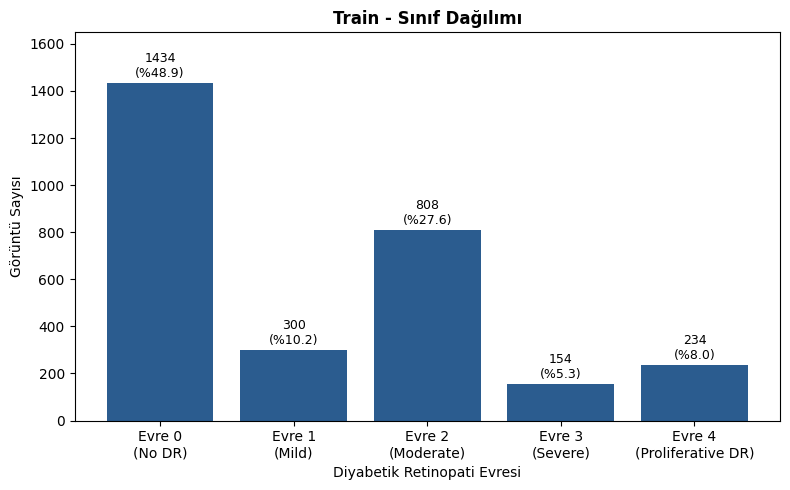


📊 Validation Sınıf Dağılımı


,Evre,Sınıf,Görüntü Sayısı,Yüzde (%)
0,0,No DR,172,46.99
1,1,Mild,40,10.93
2,2,Moderate,104,28.42
3,3,Severe,22,6.01
4,4,Proliferative DR,28,7.65


En fazla görüntü : Evre 0 (No DR) → 172
En az görüntü   : Evre 3 (Severe) → 22
Sınıf dengesizlik oranı (Max / Min): 7.82


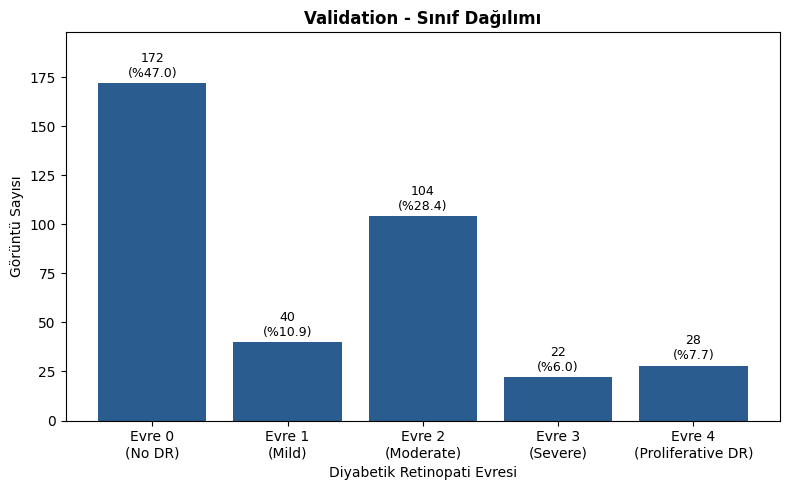


📊 Test Sınıf Dağılımı


,Evre,Sınıf,Görüntü Sayısı,Yüzde (%)
0,0,No DR,199,54.37
1,1,Mild,30,8.20
2,2,Moderate,87,23.77
3,3,Severe,17,4.64
4,4,Proliferative DR,33,9.02


En fazla görüntü : Evre 0 (No DR) → 199
En az görüntü   : Evre 3 (Severe) → 17
Sınıf dengesizlik oranı (Max / Min): 11.71


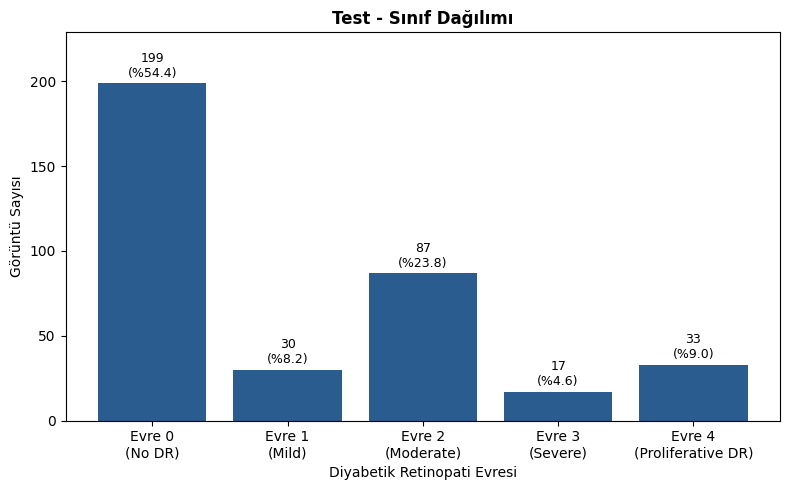

In [8]:
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

# Sınıf isimleri
class_names = {
    0: "No DR",
    1: "Mild",
    2: "Moderate",
    3: "Severe",
    4: "Proliferative DR",
}

datasets = {"Train": df_train, "Validation": df_valid, "Test": df_test}

for dataset_name, df in datasets.items():
    # Her sınıftaki görüntü sayısı
    counts = (
        df["diagnosis"]
        .value_counts()
        .reindex(range(5), fill_value=0)
        .sort_index()
    )

    # Yüzdelik dağılım
    percentages = (counts / counts.sum()) * 100

    # Sonuç tablosu
    distribution_table = pd.DataFrame({
        "Evre": counts.index,
        "Sınıf": [class_names[i] for i in counts.index],
        "Görüntü Sayısı": counts.values,
        "Yüzde (%)": percentages.round(2).values,
    })

    print(f"\n📊 {dataset_name} Sınıf Dağılımı")
    display(distribution_table)

    # Sınıf dengesizliği
    non_zero_counts = counts[counts > 0]
    max_count = non_zero_counts.max()
    min_count = non_zero_counts.min()
    imbalance_ratio = max_count / min_count

    print(
        f"En fazla görüntü : Evre {non_zero_counts.idxmax()} ({class_names[non_zero_counts.idxmax()]}) → {max_count}"
    )
    print(
        f"En az görüntü   : Evre {non_zero_counts.idxmin()} ({class_names[non_zero_counts.idxmin()]}) → {min_count}"
    )
    print(f"Sınıf dengesizlik oranı (Max / Min): {imbalance_ratio:.2f}")

    # Grafik
    fig, ax = plt.subplots(figsize=(8, 5))
    bars = ax.bar(
        [f"Evre {i}\n({class_names[i]})" for i in counts.index],
        counts.values,
        color="#2b5c8f",
    )

    ax.set_title(
        f"{dataset_name} - Sınıf Dağılımı", fontsize=12, fontweight="bold"
    )
    ax.set_xlabel("Diyabetik Retinopati Evresi", fontsize=10)
    ax.set_ylabel("Görüntü Sayısı", fontsize=10)

    # Grafik üst limitini yazılar sığsın diye biraz artırıyoruz
    ax.set_ylim(0, max_count * 1.15)

    for bar, count, percentage in zip(bars, counts.values, percentages.values):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + (max_count * 0.01),
            f"{count}\n(%{percentage:.1f})",
            ha="center",
            va="bottom",
            fontsize=9,
        )

    plt.tight_layout()
    plt.show()
    plt.close(fig)  # Bellek temizliği

 ### Ham retina resimlerinin piksel boyutları, çözünürlükleri ve renk kanalları (RGB/Grayscale) kontrol edilir.

In [34]:
# ============================================================
# HAM GÖRÜNTÜ EDA TARAMASI (Colab & VS Code Uyumlu)
# Boyut, çözünürlük ve renk kanalı kontrolü
# ============================================================

import os
import pandas as pd
from PIL import Image
from tqdm.auto import tqdm
from IPython.display import display

# ============================================================
# 0. ORTAM TESPİTİ VE DİNAMİK YOL TANIMLARI
# ============================================================
try:
    import google.colab
    DATA_DIR = "/content/drive/MyDrive/aptos2019"
    print("🚀 Google Colab ortamı algılandı.")
except ImportError:
    DATA_DIR = "aptos2019"
    print("💻 Yerel Mac ortamı algılandı.")

# Klasör öneklerini dinamik olarak belirliyoruz
PATH_PREFIXES = {
    "train": os.path.join(DATA_DIR, "train_images", "train_images"),
    "valid": os.path.join(DATA_DIR, "val_images", "val_images"),
    "test": os.path.join(DATA_DIR, "test_images", "test_images"),
}

TRAIN_IMAGE_DIR = PATH_PREFIXES["train"]
VALID_IMAGE_DIR = PATH_PREFIXES["valid"]
TEST_IMAGE_DIR = PATH_PREFIXES["test"]

# ============================================================
# EDA CACHE DOSYALARI
# ============================================================
EDA_CACHE_DIR = os.path.join(DATA_DIR, "eda_cache")
os.makedirs(EDA_CACHE_DIR, exist_ok=True)

CHECKPOINT_PATH = os.path.join(EDA_CACHE_DIR, "image_properties_checkpoint.csv")
FINAL_PATH = os.path.join(EDA_CACHE_DIR, "image_properties.csv")
SAVE_EVERY = 100


# ============================================================
# 1. FİNAL SONUÇ VARSA TEKRAR TARAMA YAPMA
# ============================================================
if os.path.exists(FINAL_PATH):
    print("✅ Tam EDA sonucu zaten mevcut. Tekrar tarama yapılmadı.")
    image_properties_df = pd.read_csv(FINAL_PATH)
    print("Toplam kayıt:", len(image_properties_df))
    display(image_properties_df.head())

else:
    # --------------------------------------------------------
    # Train + Validation + Test birleştir
    # --------------------------------------------------------
    all_df = pd.concat(
        [
            df_train.assign(split="Train", image_dir=TRAIN_IMAGE_DIR),
            df_valid.assign(split="Validation", image_dir=VALID_IMAGE_DIR),
            df_test.assign(split="Test", image_dir=TEST_IMAGE_DIR)
        ],
        ignore_index=True
    )

    # --------------------------------------------------------
    # Daha önce checkpoint oluşmuşsa kaldığı yerden devam et
    # --------------------------------------------------------
    if os.path.exists(CHECKPOINT_PATH):
        print("♻️ Önceki EDA checkpoint bulundu.")
        checkpoint_df = pd.read_csv(CHECKPOINT_PATH)
        image_properties = checkpoint_df.to_dict(orient="records")
        completed_keys = set(
            zip(
                checkpoint_df["split"].astype(str),
                checkpoint_df["id_code"].astype(str)
            )
        )
        print(f"✅ {len(completed_keys)} görüntü daha önce işlenmiş.")
    else:
        print("🆕 Checkpoint bulunamadı. Sıfırdan başlanıyor.")
        image_properties = []
        completed_keys = set()

    # --------------------------------------------------------
    # Sadece henüz işlenmemiş görüntüleri seç
    # --------------------------------------------------------
    remaining_mask = [
        (str(row["split"]), str(row["id_code"])) not in completed_keys
        for _, row in all_df.iterrows()
    ]
    remaining_df = all_df[remaining_mask].copy()
    print("İşlenecek kalan görüntü:", len(remaining_df))

    processed_since_save = 0

    # ========================================================
    # 2. GÖRÜNTÜLERİ TARA
    # ========================================================
    for _, row in tqdm(
        remaining_df.iterrows(),
        total=len(remaining_df),
        desc="Görüntüler inceleniyor"
    ):
        if "image_file" in row and pd.notnull(row["image_file"]):
            image_name = os.path.basename(str(row["image_file"]))
        else:
            image_name = f"{row['id_code']}.png"

        image_path = os.path.join(row["image_dir"], image_name)

        try:
            with Image.open(image_path) as img:
                img.load()
                width, height = img.size
                color_mode = img.mode
                channels = len(img.getbands())

            image_properties.append({
                "id_code": str(row["id_code"]),
                "split": row["split"],
                "width": width,
                "height": height,
                "resolution": f"{width}x{height}",
                "color_mode": color_mode,
                "channels": channels,
                "status": "ok"
            })
        except Exception as e:
            image_properties.append({
                "id_code": str(row["id_code"]),
                "split": row["split"],
                "width": None,
                "height": None,
                "resolution": None,
                "color_mode": None,
                "channels": None,
                "status": f"error: {str(e)}"
            })

        processed_since_save += 1

        if processed_since_save >= SAVE_EVERY:
            temp_df = pd.DataFrame(image_properties)
            temp_df.to_csv(CHECKPOINT_PATH, index=False)
            processed_since_save = 0
            print(f"\n💾 Checkpoint kaydedildi: {len(temp_df)}/{len(all_df)}")

    # ========================================================
    # 3. TARAMA BİTTİ - FİNAL DOSYAYI KAYDET
    # ========================================================
    image_properties_df = pd.DataFrame(image_properties)
    image_properties_df.to_csv(FINAL_PATH, index=False)

    print("\n✅ TAM TARAMA TAMAMLANDI.")
    print("Toplam kayıt:", len(image_properties_df))
    print("Başarılı:", (image_properties_df["status"] == "ok").sum())
    print("Final dosya:", FINAL_PATH)

    display(image_properties_df.head())

💻 Yerel Mac ortamı algılandı.
🆕 Checkpoint bulunamadı. Sıfırdan başlanıyor.
İşlenecek kalan görüntü: 3662


Görüntüler inceleniyor:   0%|          | 0/3662 [00:00<?, ?it/s]


💾 Checkpoint kaydedildi: 100/3662

💾 Checkpoint kaydedildi: 200/3662

💾 Checkpoint kaydedildi: 300/3662

💾 Checkpoint kaydedildi: 400/3662

💾 Checkpoint kaydedildi: 500/3662

💾 Checkpoint kaydedildi: 600/3662

💾 Checkpoint kaydedildi: 700/3662

💾 Checkpoint kaydedildi: 800/3662

💾 Checkpoint kaydedildi: 900/3662

💾 Checkpoint kaydedildi: 1000/3662

💾 Checkpoint kaydedildi: 1100/3662

💾 Checkpoint kaydedildi: 1200/3662

💾 Checkpoint kaydedildi: 1300/3662

💾 Checkpoint kaydedildi: 1400/3662

💾 Checkpoint kaydedildi: 1500/3662

💾 Checkpoint kaydedildi: 1600/3662

💾 Checkpoint kaydedildi: 1700/3662

💾 Checkpoint kaydedildi: 1800/3662

💾 Checkpoint kaydedildi: 1900/3662

💾 Checkpoint kaydedildi: 2000/3662

💾 Checkpoint kaydedildi: 2100/3662

💾 Checkpoint kaydedildi: 2200/3662

💾 Checkpoint kaydedildi: 2300/3662

💾 Checkpoint kaydedildi: 2400/3662

💾 Checkpoint kaydedildi: 2500/3662

💾 Checkpoint kaydedildi: 2600/3662

💾 Checkpoint kaydedildi: 2700/3662

💾 Checkpoint kaydedildi: 2800/3662



,id_code,split,width,height,resolution,color_mode,channels,status
0,1ae8c165fd53,Train,3216,2136,3216x2136,RGB,3,ok
1,1b329a127307,Train,2588,1958,2588x1958,RGB,3,ok
2,1b32e1d775ea,Train,1504,1000,1504x1000,RGB,3,ok
3,1b3647865779,Train,819,614,819x614,RGB,3,ok
4,1b398c0494d1,Train,1050,1050,1050x1050,RGB,3,ok


In [35]:
# Ham görüntü analizi özeti

print("📐 GÖRÜNTÜ BOYUTLARI")
display(
    image_properties_df[["width", "height"]].describe()
)

print("\n🖼️ TOPLAM FARKLI ÇÖZÜNÜRLÜK SAYISI")
print(image_properties_df["resolution"].nunique())

print("\n🖼️ EN SIK GÖRÜLEN 10 ÇÖZÜNÜRLÜK")
display(
    image_properties_df["resolution"]
    .value_counts()
    .head(10)
)

print("\n🎨 RENK MODLARI")
display(
    image_properties_df["color_mode"].value_counts()
)

print("\n📺 KANAL SAYILARI")
display(
    image_properties_df["channels"].value_counts()
)

📐 GÖRÜNTÜ BOYUTLARI


,width,height
count,3662.000000,3662.000000
mean,2015.176679,1526.830147
std,884.301940,542.663120
min,474.000000,358.000000
25%,1050.000000,1050.000000
50%,2144.000000,1536.000000
75%,2588.000000,1958.000000
max,4288.000000,2848.000000



🖼️ TOPLAM FARKLI ÇÖZÜNÜRLÜK SAYISI
17

🖼️ EN SIK GÖRÜLEN 10 ÇÖZÜNÜRLÜK


resolution
1050x1050    974
2416x1736    638
2588x1958    533
3216x2136    410
2048x1536    351
819x614      287
3388x2588    141
1504x1000     92
1844x1226     61
4288x2848     52
Name: count, dtype: int64


🎨 RENK MODLARI


color_mode
RGB    3662
Name: count, dtype: int64


📺 KANAL SAYILARI


channels
3    3662
Name: count, dtype: int64

Ham retina görüntülerinin çözünürlüklerinin sabit olmadığı ve veri setinde 17 farklı çözünürlük bulunduğu görülmüştür. Görüntü boyutları 474×358 ile 4288×2848 arasında değişmektedir. Tüm 3662 görüntünün RGB formatında ve 3 kanallı olduğu doğrulanmıştır. Bu nedenle modelleme öncesinde görüntülerin ortak bir boyuta yeniden ölçeklendirilmesi gerekmektedir.

### Veri Temizleme ve Kalite Kontrol Betiği

Bozuk, açılmayan veya aşırı karanlık görseller için hızlı bir veri temizleme kontrol betiği

In [39]:
# ============================================================
# VERİ TEMİZLEME VE KALİTE KONTROLÜ (Colab & VS Code Uyumlu)
# Bozuk / açılamayan / aşırı karanlık görüntü kontrolü
# ============================================================

import os
import pandas as pd

from PIL import Image, ImageStat
from concurrent.futures import ThreadPoolExecutor, as_completed
from tqdm.auto import tqdm


# ============================================================
# ORTAM TESPİTİ VE CACHE AYARLARI
# ============================================================
try:
    import google.colab
    DATA_DIR = "/content/drive/MyDrive/aptos2019"
    print("🚀 Google Colab ortamı algılandı.")
except ImportError:
    DATA_DIR = "aptos2019"
    print("💻 Yerel Mac ortamı algılandı.")

QUALITY_CACHE_DIR = os.path.join(DATA_DIR, "quality_cache")

os.makedirs(
    QUALITY_CACHE_DIR,
    exist_ok=True
)

TRAIN_QUALITY_PATH = os.path.join(
    QUALITY_CACHE_DIR,
    "train_quality_results.csv"
)

# Klasör önekini dinamik tanımla
TRAIN_IMAGE_DIR = os.path.join(DATA_DIR, "train_images", "train_images")


# ============================================================
# TEK BİR GÖRÜNTÜYÜ KONTROL ET
# ============================================================

def verify_single_image(
    row,
    image_dir,
    brightness_threshold=12.0
):

    # --------------------------------------------------------
    # Dosya adını belirle
    # --------------------------------------------------------

    if (
        "image_file" in row
        and pd.notnull(row["image_file"])
    ):

        img_file = os.path.basename(
            str(row["image_file"])
        )

    else:

        img_file = (
            f"{row['id_code']}.png"
        )


    # --------------------------------------------------------
    # Tam yol
    # --------------------------------------------------------

    image_path = os.path.join(
        image_dir,
        img_file
    )


    try:

        # ----------------------------------------------------
        # Görüntüyü aç ve gerçekten yükle
        # ----------------------------------------------------

        with Image.open(image_path) as img:

            img = img.convert("RGB")
            img.load()

            # -----------------------------------------------
            # Ortalama parlaklık
            # -----------------------------------------------

            gray_img = img.convert("L")

            stat = ImageStat.Stat(
                gray_img
            )

            mean_brightness = stat.mean[0]


        # ----------------------------------------------------
        # Aşırı karanlık mı?
        # ----------------------------------------------------

        if mean_brightness < brightness_threshold:

            status = "dark"

        else:

            status = "valid"


        return {
            "index": row.name,
            "id_code": str(row["id_code"]),
            "path": image_path,
            "brightness": mean_brightness,
            "status": status,
            "error": None
        }


    except Exception as e:

        return {
            "index": row.name,
            "id_code": str(row["id_code"]),
            "path": image_path,
            "brightness": None,
            "status": "corrupted",
            "error": str(e)
        }


# ============================================================
# TÜM DATASET'İ KONTROL ET
# ============================================================

def check_dataset_quality_fast(
    df,
    image_dir,
    cache_path,
    brightness_threshold=12.0,
    max_workers=4
):

    # ========================================================
    # CACHE VARSA TEKRAR TARAMA YAPMA
    # ========================================================

    if os.path.exists(cache_path):

        print(
            "✅ Kalite kontrol sonucu zaten mevcut. "
            "Tekrar tarama yapılmadı."
        )

        quality_df = pd.read_csv(
            cache_path
        )


    # ========================================================
    # CACHE YOKSA GÖRÜNTÜLERİ TARA
    # ========================================================

    else:

        print(
            f"🚀 {len(df)} görüntü kalite kontrolünden geçiriliyor..."
        )

        rows = [
            row
            for _, row in df.iterrows()
        ]

        results = []


        # ----------------------------------------------------
        # Paralellik ayarı
        # ----------------------------------------------------

        with ThreadPoolExecutor(
            max_workers=max_workers
        ) as executor:

            futures = [
                executor.submit(
                    verify_single_image,
                    row,
                    image_dir,
                    brightness_threshold
                )
                for row in rows
            ]


            for future in tqdm(
                as_completed(futures),
                total=len(futures),
                desc="Görüntüler kontrol ediliyor"
            ):

                results.append(
                    future.result()
                )


        quality_df = pd.DataFrame(
            results
        )


        # ----------------------------------------------------
        # Sonucu kaydet
        # ----------------------------------------------------

        quality_df.to_csv(
            cache_path,
            index=False
        )

        print(
            "\n💾 Kalite kontrol sonucu kaydedildi:"
        )

        print(
            cache_path
        )


    # ========================================================
    # SONUÇLARI AYIR
    # ========================================================

    valid_df = quality_df[
        quality_df["status"] == "valid"
    ]

    dark_df = quality_df[
        quality_df["status"] == "dark"
    ]

    corrupted_df = quality_df[
        quality_df["status"] == "corrupted"
    ]


    valid_indices = (
        valid_df["index"]
        .astype(int)
        .tolist()
    )

    dark_list = (
        dark_df
        .to_dict(
            orient="records"
        )
    )

    corrupted_list = (
        corrupted_df
        .to_dict(
            orient="records"
        )
    )


    # ========================================================
    # RAPOR
    # ========================================================

    print("\n" + "=" * 45)

    print(
        "📋 VERİ KALİTE KONTROL SONUÇLARI"
    )

    print("=" * 45)

    print(
        f"✅ Sağlam ve geçerli görsel : "
        f"{len(valid_df)}"
    )

    print(
        f"⚠️ Aşırı karanlık görsel   : "
        f"{len(dark_df)}"
    )

    print(
        f"❌ Bozuk / bulunamayan     : "
        f"{len(corrupted_df)}"
    )


    return (
        valid_indices,
        corrupted_list,
        dark_list,
        quality_df
    )


# ============================================================
# TRAIN DATASET KALİTE KONTROLÜ
# ============================================================

valid_idx, corrupted_list, dark_list, train_quality_df = (
    check_dataset_quality_fast(
        df=df_train,
        image_dir=TRAIN_IMAGE_DIR,
        cache_path=TRAIN_QUALITY_PATH,
        brightness_threshold=12.0,
        max_workers=4
    )
)

💻 Yerel Mac ortamı algılandı.
🚀 2930 görüntü kalite kontrolünden geçiriliyor...


Görüntüler kontrol ediliyor:   0%|          | 0/2930 [00:00<?, ?it/s]


💾 Kalite kontrol sonucu kaydedildi:
aptos2019/quality_cache/train_quality_results.csv

📋 VERİ KALİTE KONTROL SONUÇLARI
✅ Sağlam ve geçerli görsel : 2930
⚠️ Aşırı karanlık görsel   : 0
❌ Bozuk / bulunamayan     : 0


### Göz etrafındaki siyah boşlukları otomatik kesen Auto-Crop uygulama.

CLAHE :Kılcal damarları netleştirmek için CLAHE (Kontrast Artırma) algoritması kodlanır ve görsellere uygulanır

macOS multiprocessing (spawn) hatasını önlemek amacıyla auto_crop, apply_clahe ve APTOSDataset yapıları Jupyter defterinden kaldırılarak harici dataset.py dosyasına taşınmıştır.

# PyTorch Dataset & Data Augmentation

### Albumentations kütüphanesi kullanılarak rastgele döndürme (rotation), yatay/dikey çevirme (flip) gibi Data Augmentation süreçleri (Eğitim (train) veri setinde çeşitliliği artırmak için güçlü dönüşümler eklerken, doğrulama (valid) veri setinde resimlerin orijinal yapısını koruyup sadece boyutlandırma ve normalize etme işlemleri uyguluyoruz)

In [9]:
import os
import numpy as np
import pandas as pd
from PIL import Image
import torch
from torch.utils.data import Dataset


class APTOSDataset(Dataset):

    def __init__(self, df, folder_prefix="", transform=None):
        self.df = df.reset_index(drop=True)
        self.folder_prefix = folder_prefix
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_file = (
            row["image_file"]
            if "image_file" in row and pd.notnull(row["image_file"])
            else f"{row['id_code']}.png"
        )
        label = (
            int(row["diagnosis"])
            if "diagnosis" in row and pd.notnull(row["diagnosis"])
            else -1
        )

        img_path = os.path.join(self.folder_prefix, img_file)

        try:
            # 1. Yerel dosyadan PIL -> NumPy
            img_pil = Image.open(img_path).convert("RGB")
            img_np = np.array(img_pil)

            # 2. Auto-Crop Uygulaması
            img_cropped = auto_crop(img_np, threshold=10, padding=5)

            # 3. CLAHE Uygulaması (Kılcal damarları netleştirme)
            img_final = apply_clahe(img_cropped)

        except Exception:
            # Okuma hatasında 224x224 siyah görüntü fallback'i
            img_final = np.zeros((224, 224, 3), dtype=np.uint8)

        # 4. Albumentations Dönüşümü
        if self.transform:
            augmented = self.transform(image=img_final)
            img_tensor = augmented["image"]
        else:
            img_tensor = (
                torch.from_numpy(img_final).permute(2, 0, 1).float() / 255.0
            )

        return img_tensor, torch.tensor(label, dtype=torch.long)

In [10]:
import albumentations as A
from albumentations.pytorch import ToTensorV2
from torch.utils.data import DataLoader

# 1. Transform Tanımları
train_transform = A.Compose(
    [
        A.Resize(224, 224),
        A.HorizontalFlip(p=0.5),
        A.VerticalFlip(p=0.5),
        A.RandomRotate90(p=0.5),
        A.ShiftScaleRotate(
            shift_limit=0.05, scale_limit=0.1, rotate_limit=15, p=0.5
        ),
        A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
        ToTensorV2(),
    ]
)

val_transform = A.Compose(
    [
        A.Resize(224, 224),
        A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
        ToTensorV2(),
    ]
)

# 2. Dataset ve DataLoader Oluşturma
train_dataset = APTOSDataset(
    df=df_train,
    folder_prefix=PATH_PREFIXES["train"],
    transform=train_transform,
)

train_loader = DataLoader(
    train_dataset, batch_size=16, shuffle=True, num_workers=0
)

# 3. İlk Batch Kontrolü
images, labels = next(iter(train_loader))

print("✅ Albumentations Entegrasyonu Başarılı!")
print(f"📦 Batch Görüntü Şekli (Tensor) : {images.shape}")  # [16, 3, 224, 224]
print(f"🏷️ Batch Etiket Şekli (Tensor)  : {labels.shape}")  # [16]
print(f"📊 Veri Tipi                    : {images.dtype}")  # torch.float32

/Users/cerenkocabas/.pyenv/versions/3.12.9/envs/workintech/lib/python3.12/site-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


✅ Albumentations Entegrasyonu Başarılı!
📦 Batch Görüntü Şekli (Tensor) : torch.Size([16, 3, 224, 224])
🏷️ Batch Etiket Şekli (Tensor)  : torch.Size([16])
📊 Veri Tipi                    : torch.float32


** Albumentations kütüphanesi standart PIL görselleri yerine NumPy dizileri (np.ndarray) ile çalışır. Bu yüzden __getitem__ içinde kırpma işleminden sonra resmi NumPy formatında tutup transform(image=img_cropped) şeklinde çağırmamız gerekir

In [11]:
import os
import numpy as np
import pandas as pd
from PIL import Image
import torch
from torch.utils.data import Dataset


class APTOSDataset(Dataset):

    def __init__(self, df, folder_prefix="", transform=None):
        self.df = df.reset_index(drop=True)
        self.folder_prefix = folder_prefix
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_file = (
            row["image_file"]
            if "image_file" in row and pd.notnull(row["image_file"])
            else f"{row['id_code']}.png"
        )
        label = (
            int(row["diagnosis"])
            if "diagnosis" in row and pd.notnull(row["diagnosis"])
            else -1
        )

        # 1. Yerel dosyadan resmi okuma
        img_path = os.path.join(self.folder_prefix, img_file)

        try:
            # 2. PIL -> NumPy (Albumentations için np.ndarray şarttır)
            img_pil = Image.open(img_path).convert("RGB")
            img_np = np.array(img_pil)

            # 3. Kırpma işlemi (Auto-Crop)
            img_cropped = auto_crop(img_np, threshold=10, padding=5)

            # 4. Kılcal Damarları Netleştirme (CLAHE)
            img_final = apply_clahe(img_cropped)

        except Exception:
            # Görsel okuma hatası olursa 224x224 siyah görüntü oluştur
            img_final = np.zeros((224, 224, 3), dtype=np.uint8)

        # 5. Albumentations Augmentation Uygulama
        if self.transform:
            augmented = self.transform(image=img_final)
            img_tensor = augmented["image"]
        else:
            img_tensor = (
                torch.from_numpy(img_final).permute(2, 0, 1).float() / 255.0
            )

        return img_tensor, torch.tensor(label, dtype=torch.long)

###PyTorch Dataset ve DataLoader sınıfları kodlanır.

####DataDataLoader'ları Hazırlama

###Eğitim, doğrulama (validation) ve test veri yükleyicilerinin sorunsuz veri beslediği test etme

✅ Train Loader: 2930 resim | 92 batch
✅ Val Loader  : 366 resim | 12 batch
✅ Test Loader : 366 resim | 12 batch

✅ VERİ BORUSU TESTİ BAŞARILI!
• Batch Resim Boyutu (Shape) : torch.Size([32, 3, 224, 224])
• Batch Etiket Boyutu (Shape): torch.Size([32])
• Veri Tipi (Dtype)          : torch.float32
• Etiket Örnekleri (İlk 5)   : [0, 4, 0, 0, 0]


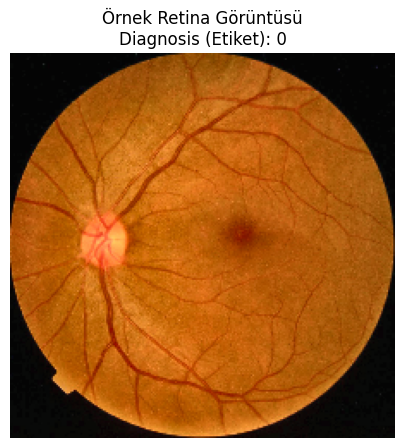

In [12]:
import os
import matplotlib.pyplot as plt
import numpy as np
import torch
from torch.utils.data import DataLoader
from dataset import auto_crop, apply_clahe, APTOSDataset

# ==============================================================================
# 1. DATALOADER'LARI TANIMLAMA
# ==============================================================================
num_workers = 0

# Train Dataset & Loader
train_dataset = APTOSDataset(
    df=df_train,
    folder_prefix=PATH_PREFIXES["train"],
    transform=train_transform,
)

# Validation Dataset & Loader
val_dataset = APTOSDataset(
    df=df_valid,
    folder_prefix=PATH_PREFIXES["valid"],
    transform=val_transform,
)

# Test Dataset & Loader
test_dataset = APTOSDataset(
    df=df_test,
    folder_prefix=PATH_PREFIXES["test"],
    transform=val_transform,
)

# DataLoader Yükleyicileri (Batch Size: 32)
train_loader = DataLoader(
    train_dataset, batch_size=32, shuffle=True, num_workers=num_workers
)
val_loader = DataLoader(
    val_dataset, batch_size=32, shuffle=False, num_workers=num_workers
)
test_loader = DataLoader(
    test_dataset, batch_size=32, shuffle=False, num_workers=num_workers
)

print(
    f"✅ Train Loader: {len(train_dataset)} resim | {len(train_loader)} batch"
)
print(f"✅ Val Loader  : {len(val_dataset)} resim | {len(val_loader)} batch")
print(f"✅ Test Loader : {len(test_dataset)} resim | {len(test_loader)} batch\n")

# ==============================================================================
# 2. VERİ BORUSU DOĞRULAMA VE GÖRSELLEŞTİRME TESTİ
# ==============================================================================
try:
    images, labels = next(iter(train_loader))

    print("✅ VERİ BORUSU TESTİ BAŞARILI!")
    print(f"• Batch Resim Boyutu (Shape) : {images.shape}")  # [32, 3, 224, 224]
    print(f"• Batch Etiket Boyutu (Shape): {labels.shape}")  # [32]
    print(f"• Veri Tipi (Dtype)          : {images.dtype}")
    print(f"• Etiket Örnekleri (İlk 5)   : {labels[:5].tolist()}")

    sample_img = images[0].permute(1, 2, 0).cpu().numpy()
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])

    sample_img = std * sample_img + mean
    sample_img = np.clip(sample_img, 0, 1)

    plt.figure(figsize=(5, 5))
    plt.imshow(sample_img)
    plt.title(f"Örnek Retina Görüntüsü\nDiagnosis (Etiket): {labels[0].item()}")
    plt.axis("off")
    plt.show()

except Exception as e:
    print("❌ Data Borusu Testinde Hata Oluştu:")
    print(e)

# Model Mimarisi & Kayıp Fonksiyonu (Loss)

## Baseline (temel) basit bir custom CNN veya hafif model mimarisi hazırlama

In [13]:
import torch
import torch.nn as nn
import torch.nn.functional as F


# ==============================================================================
# BASELINE CUSTOM CNN MİMARİSİ
# ==============================================================================
class BaselineCNN(nn.Module):

    def __init__(self, num_classes=5):
        super(BaselineCNN, self).__init__()

        # 1. Evrişim (Convolution) Katmanları
        # Giriş Boyutu: [Batch, 3, 224, 224]
        self.conv1 = nn.Conv2d(
            in_channels=3, out_channels=16, kernel_size=3, padding=1
        )
        self.bn1 = nn.BatchNorm2d(16)

        self.conv2 = nn.Conv2d(
            in_channels=16, out_channels=32, kernel_size=3, padding=1
        )
        self.bn2 = nn.BatchNorm2d(32)

        self.conv3 = nn.Conv2d(
            in_channels=32, out_channels=64, kernel_size=3, padding=1
        )
        self.bn3 = nn.BatchNorm2d(64)

        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)  # Boyutu yarıya indirir

        # Hesaplama: 224 -> Pool1 -> 112 -> Pool2 -> 56 -> Pool3 -> 28
        # Düzleştirilmiş Vektör: 64 * 28 * 28 = 50,176

        # 2. Tam Bağlantılı (Classifier) Katmanlar
        self.fc1 = nn.Linear(64 * 28 * 28, 128)
        self.dropout = nn.Dropout(0.3)
        self.fc2 = nn.Linear(128, num_classes)

    def forward(self, x):
        x = self.pool(F.relu(self.bn1(self.conv1(x))))  # [Batch, 16, 112, 112]
        x = self.pool(F.relu(self.bn2(self.conv2(x))))  # [Batch, 32, 56, 56]
        x = self.pool(F.relu(self.bn3(self.conv3(x))))  # [Batch, 64, 28, 28]

        # Flatten (Düzleştirme)
        x = x.view(x.size(0), -1)

        # Sınıflandırma
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)

        return x


# ==============================================================================
# OTOMATİK CİHAZ SEÇİMİ (CUDA / MPS / CPU)
# ==============================================================================
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

baseline_model = BaselineCNN(num_classes=5).to(device)

print(f"✅ Baseline Custom CNN hazırlandı!")
print(f"🚀 Aktif Cihaz: {device}")

✅ Baseline Custom CNN hazırlandı!
🚀 Aktif Cihaz: mps


### Baseline Modeli Test Etme (Dry Run)
Modelin beklenen girdi boyutlarını alıp sorunsuz çıktı verip vermediğini test etmek için train_loader'dan tek bir batch geçirerek doğrulayalım:

In [14]:
# Modeli sahte/test verisiyle kontrol etme (SMOKE TESTİ)
images, labels = next(iter(train_loader))
images = images.to(device)

with torch.no_grad():
    outputs = baseline_model(images)

print(f"• Girdi Batch Boyutu : {images.shape}")   # [32, 3, 224, 224]
print(f"• Çıktı Batch Boyutu : {outputs.shape}")  # [32, 5] (32 resim için 5 sınıf skoru)
print("✅ Baseline model sorunsuz ileri besleme (forward pass) yapıyor!")

• Girdi Batch Boyutu : torch.Size([32, 3, 224, 224])
• Çıktı Batch Boyutu : torch.Size([32, 5])
✅ Baseline model sorunsuz ileri besleme (forward pass) yapıyor!


##Torchvision veya timm üzerinden EfficientNet-B0 ve ResNet50 modelleri çağrılır, son çıktı katmanları 5 sınıfa uyarlanır. Sınıf dengesizliği için Weighted Cross-Entropy ağırlıkları hesaplanır.

In [40]:
# ============================================================
# EfficientNet-B0 + ResNet50
# 5 sınıfa uyarlama + Weighted Cross-Entropy
# ============================================================

import torch
import torch.nn as nn

from torchvision.models import (
    efficientnet_b0,
    EfficientNet_B0_Weights,
    resnet50,
    ResNet50_Weights
)

# Cihaz
device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "mps" if torch.backends.mps.is_available()
    else "cpu"
)

NUM_CLASSES = 5

print("Kullanılan cihaz:", device)


# ============================================================
# 1. SINIF AĞIRLIKLARINI HESAPLA
# ============================================================

# Sadece TRAIN seti kullanılmalı
class_counts = (
    df_train["diagnosis"]
    .value_counts()
    .reindex(range(NUM_CLASSES), fill_value=0)
    .sort_index()
)

print("\nTrain sınıf dağılımı:")
print(class_counts)


# Weighted Cross-Entropy için ağırlık:
# total_samples / (num_classes * class_count)

total_samples = class_counts.sum()

class_weights = (
    total_samples /
    (NUM_CLASSES * class_counts.values)
)

class_weights = torch.tensor(
    class_weights,
    dtype=torch.float32
).to(device)

print("\nSınıf ağırlıkları:")
for i, weight in enumerate(class_weights):
    print(f"Evre {i}: {weight.item():.4f}")


# ============================================================
# 2. WEIGHTED CROSS-ENTROPY LOSS
# ============================================================

criterion = nn.CrossEntropyLoss(
    weight=class_weights
)

print("\n✅ Weighted Cross-Entropy Loss hazır.")


# ============================================================
# 3. EFFICIENTNET-B0
# ============================================================

efficientnet_model = efficientnet_b0(
    weights=EfficientNet_B0_Weights.DEFAULT
)

# EfficientNet-B0'nun son Linear katmanının giriş boyutu
efficientnet_in_features = (
    efficientnet_model.classifier[1].in_features
)

# Son katmanı 5 sınıfa çevir
efficientnet_model.classifier[1] = nn.Linear(
    efficientnet_in_features,
    NUM_CLASSES
)

efficientnet_model = efficientnet_model.to(device)

print("✅ EfficientNet-B0 hazır: çıktı sınıfı = 5")


# ============================================================
# 4. RESNET50
# ============================================================

resnet50_model = resnet50(
    weights=ResNet50_Weights.DEFAULT
)

# ResNet50'nin son FC katmanının giriş boyutu
resnet_in_features = resnet50_model.fc.in_features

# Son katmanı 5 sınıfa çevir
resnet50_model.fc = nn.Linear(
    resnet_in_features,
    NUM_CLASSES
)

resnet50_model = resnet50_model.to(device)

print("✅ ResNet50 hazır: çıktı sınıfı = 5")

Kullanılan cihaz: mps

Train sınıf dağılımı:
diagnosis
0    1434
1     300
2     808
3     154
4     234
Name: count, dtype: int64

Sınıf ağırlıkları:
Evre 0: 0.4086
Evre 1: 1.9533
Evre 2: 0.7252
Evre 3: 3.8052
Evre 4: 2.5043

✅ Weighted Cross-Entropy Loss hazır.
✅ EfficientNet-B0 hazır: çıktı sınıfı = 5
✅ ResNet50 hazır: çıktı sınıfı = 5


In [18]:
# Model çıktı boyutlarını test et

dummy_input = torch.randn(
    2, 3, 224, 224
).to(device)

efficientnet_model.eval()
resnet50_model.eval()

with torch.no_grad():

    eff_output = efficientnet_model(dummy_input)
    res_output = resnet50_model(dummy_input)

print(
    "EfficientNet-B0 çıktı:",
    eff_output.shape
)

print(
    "ResNet50 çıktı:",
    res_output.shape
)

EfficientNet-B0 çıktı: torch.Size([2, 5])
ResNet50 çıktı: torch.Size([2, 5])


### EfficientNet-B0, ResNet50 ve Weighted Cross-Entropy
Bu aşamada transfer learning yaklaşımı kullanılarak torchvision üzerinden önceden eğitilmiş EfficientNet-B0 ve ResNet50 modelleri projeye dahil edilmiştir. Her iki modelin son sınıflandırma katmanı, diyabetik retinopati veri setindeki 5 sınıfı (Evre 0–4) tahmin edecek şekilde yeniden düzenlenmiştir.

Eğitim veri setinde belirgin sınıf dengesizliği bulunduğu için yalnızca eğitim verisindeki sınıf frekansları kullanılarak sınıf ağırlıkları hesaplanmıştır. Bu ağırlıklar Weighted Cross-Entropy Loss fonksiyonuna aktarılmış ve az örneğe sahip sınıflardaki hataların eğitim sırasında daha fazla dikkate alınması amaçlanmıştır.



##Model değerlendirme metrikleri için fonksiyonlar yazılır: Accuracy, Precision, Recall ve QWK (Quadratic Weighted Kappa)

In [19]:
# ============================================================

# MODEL DEĞERLENDİRME METRİKLERİ

# Accuracy, Precision, Recall ve QWK

# ============================================================



from sklearn.metrics import (

accuracy_score,

precision_score,

recall_score,

cohen_kappa_score

)





def calculate_metrics(y_true, y_pred):

    # Accuracy
    accuracy = accuracy_score(

    y_true,

    y_pred

    )



    # Precision
    # Sınıf dengesizliği nedeniyle macro average kullanıyoruz
    precision = precision_score(

    y_true,

    y_pred,

    average="macro",

    zero_division=0

    )



    # Recall
    recall = recall_score(

    y_true,

    y_pred,

    average="macro",

    zero_division=0

    )



    # Quadratic Weighted Kappa
    qwk = cohen_kappa_score(

    y_true,

    y_pred,

    weights="quadratic"

    )



    metrics = {

    "Accuracy": accuracy,

    "Precision": precision,

    "Recall": recall,

    "QWK": qwk

    }

    return metrics

In [21]:
import torch


def evaluate_model_performance(model, dataloader, device):
    """Modelden tahminleri toplar ve hesaplanan metrikleri döner."""
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)

            outputs = model(images)
            _, preds = torch.max(outputs, 1)

            all_preds.extend(preds.cpu().numpy())
            # Güvenli kullanım için cpu().numpy()
            all_labels.extend(labels.cpu().numpy())

    # Önceki hücrede tanımladığınız metrik fonksiyonunu çağırır
    metrics = calculate_metrics(all_labels, all_preds)
    return metrics, all_labels, all_preds

In [22]:
# Metrik fonksiyonunu hızlı test et

y_true_test = [0, 1, 2, 3, 4, 2, 0, 1]
y_pred_test = [0, 1, 2, 2, 4, 2, 0, 0]

test_metrics = calculate_metrics(
    y_true_test,
    y_pred_test
)

print("✅ Metrik fonksiyonları çalışıyor.\n")

for metric_name, value in test_metrics.items():
    print(
        f"{metric_name}: {value:.4f}"
    )

✅ Metrik fonksiyonları çalışıyor.

Accuracy: 0.7500
Precision: 0.6667
Recall: 0.7000
QWK: 0.9292


### Model Değerlendirme Metrikleri

Model performansını yalnızca doğruluk oranı üzerinden değerlendirmek yerine, sınıf dengesizliğini ve diyabetik retinopati evrelerinin sıralı yapısını dikkate alan bir değerlendirme altyapısı hazırlanmıştır.

Bu kapsamda **Accuracy**, **Macro Precision**, **Macro Recall** ve **Quadratic Weighted Kappa (QWK)** metriklerini hesaplayan bir fonksiyon oluşturulmuştur.

`Macro Precision` ve `Macro Recall`, her sınıfa eşit önem vererek özellikle az örneğe sahip sınıfların performansının da değerlendirmeye dahil edilmesini sağlar. `QWK` metriği ise sınıfların 0'dan 4'e sıralı yapısını dikkate alarak, tahmin edilen sınıf ile gerçek sınıf arasındaki hata büyüklüğünü değerlendirir.

Bu metrikler daha sonraki aşamalarda EfficientNet-B0, ResNet50 ve diğer modellerin performanslarını karşılaştırmak için kullanılacaktır.

In [23]:
import os

# ==============================================================================
# OTOMATİK ORTAM ALGILAMA — Checkpoint Klasörü
# ==============================================================================
try:
    import google.colab
    CHECKPOINT_DIR = "/content/drive/MyDrive/aptos2019/checkpoints"
    print("🚀 Google Colab ortamı algılandı.")
except ImportError:
    CHECKPOINT_DIR = "checkpoints"
    print("💻 Yerel Mac ortamı algılandı.")

os.makedirs(CHECKPOINT_DIR, exist_ok=True)

print("✅ Model kayıt klasörü hazır:")
print(CHECKPOINT_DIR)

💻 Yerel Mac ortamı algılandı.
✅ Model kayıt klasörü hazır:
checkpoints


In [41]:
import os
import torch
import matplotlib.pyplot as plt

from torch.optim import AdamW
from torch.optim.lr_scheduler import ReduceLROnPlateau
from IPython.display import clear_output


def train_model(
    model,
    model_name,
    train_loader,
    val_loader,
    criterion,
    device,
    num_epochs=15,
    learning_rate=1e-4,
    early_stopping_patience=4,
    resume=True
):

    # --------------------------------------------------------
    # Optimizer
    # --------------------------------------------------------
    optimizer = AdamW(
        model.parameters(),
        lr=learning_rate,
        weight_decay=1e-4
    )

    # --------------------------------------------------------
    # Learning Rate Scheduler
    # Validation loss gelişmezse learning rate düşürülür
    # --------------------------------------------------------
    scheduler = ReduceLROnPlateau(
        optimizer,
        mode="min",
        factor=0.5,
        patience=2
    )

    # --------------------------------------------------------
    # Model kayıt yolları
    # --------------------------------------------------------
    best_model_path = os.path.join(
        CHECKPOINT_DIR,
        f"{model_name}_best_model.pth"
    )

    checkpoint_path = os.path.join(
        CHECKPOINT_DIR,
        f"{model_name}_last_checkpoint.pth"
    )

    # --------------------------------------------------------
    # Başlangıç değerleri
    # --------------------------------------------------------
    train_losses = []
    val_losses = []

    best_val_loss = float("inf")
    early_stop_counter = 0
    start_epoch = 0

    # --------------------------------------------------------
    # Önceden yarım kalmış eğitim varsa devam et
    # --------------------------------------------------------
    if resume and os.path.exists(checkpoint_path):

        print("♻️ Önceki checkpoint bulundu.")

        checkpoint = torch.load(
            checkpoint_path,
            map_location=device,
            weights_only=False
        )

        model.load_state_dict(
            checkpoint["model_state_dict"]
        )

        optimizer.load_state_dict(
            checkpoint["optimizer_state_dict"]
        )

        scheduler.load_state_dict(
            checkpoint["scheduler_state_dict"]
        )

        start_epoch = checkpoint["epoch"] + 1

        best_val_loss = checkpoint["best_val_loss"]

        train_losses = checkpoint.get(
            "train_losses",
            []
        )

        val_losses = checkpoint.get(
            "val_losses",
            []
        )

        early_stop_counter = checkpoint.get(
            "early_stop_counter",
            0
        )

        print(
            f"✅ Eğitim Epoch {start_epoch + 1}'den "
            f"devam edecek."
        )

    # ========================================================
    # EĞİTİM DÖNGÜSÜ
    # ========================================================
    for epoch in range(start_epoch, num_epochs):

        # ====================================================
        # TRAIN
        # ====================================================
        model.train()

        running_train_loss = 0.0

        for images, labels in train_loader:

            images = images.to(device)
            labels = labels.to(device)

            # Önceki gradientleri temizle
            optimizer.zero_grad()

            # Forward pass
            outputs = model(images)

            # Loss
            loss = criterion(outputs, labels)

            # Backpropagation
            loss.backward()

            # Model ağırlıklarını güncelle
            optimizer.step()

            running_train_loss += (
                loss.item() * images.size(0)
            )

        train_loss = (
            running_train_loss /
            len(train_loader.dataset)
        )

        # ====================================================
        # VALIDATION
        # ====================================================
        model.eval()

        running_val_loss = 0.0
        correct = 0
        total = 0

        with torch.no_grad():

            for images, labels in val_loader:

                images = images.to(device)
                labels = labels.to(device)

                outputs = model(images)

                loss = criterion(
                    outputs,
                    labels
                )

                running_val_loss += (
                    loss.item() * images.size(0)
                )

                predictions = torch.argmax(
                    outputs,
                    dim=1
                )

                correct += (
                    predictions == labels
                ).sum().item()

                total += labels.size(0)

        val_loss = (
            running_val_loss /
            len(val_loader.dataset)
        )

        val_accuracy = correct / total

        # ----------------------------------------------------
        # Loss geçmişi
        # ----------------------------------------------------
        train_losses.append(train_loss)
        val_losses.append(val_loss)

        # ----------------------------------------------------
        # Learning Rate Scheduler
        # ----------------------------------------------------
        scheduler.step(val_loss)

        current_lr = optimizer.param_groups[0]["lr"]

        # ====================================================
        # EN İYİ MODELİ KAYDET
        # ====================================================
        if val_loss < best_val_loss:

            best_val_loss = val_loss
            early_stop_counter = 0

            torch.save(
                model.state_dict(),
                best_model_path
            )

            model_status = "💾 Yeni en iyi model kaydedildi."

        else:

            early_stop_counter += 1

            model_status = (
                f"Early Stopping sayacı: "
                f"{early_stop_counter}/"
                f"{early_stopping_patience}"
            )

        # ====================================================
        # HER EPOCH SONUNDA CHECKPOINT
        # ====================================================
        torch.save(
            {
                "epoch": epoch,
                "model_state_dict":
                    model.state_dict(),

                "optimizer_state_dict":
                    optimizer.state_dict(),

                "scheduler_state_dict":
                    scheduler.state_dict(),

                "best_val_loss":
                    best_val_loss,

                "train_losses":
                    train_losses,

                "val_losses":
                    val_losses,

                "early_stop_counter":
                    early_stop_counter
            },
            checkpoint_path
        )

        # ====================================================
        # ANLIK LOSS GRAFİĞİ
        # ====================================================
        clear_output(wait=True)

        print(f"Model: {model_name}")
        print(f"Epoch: {epoch + 1}/{num_epochs}")
        print(f"Train Loss : {train_loss:.4f}")
        print(f"Val Loss   : {val_loss:.4f}")
        print(f"Val Accuracy: {val_accuracy:.4f}")
        print(f"Learning Rate: {current_lr:.7f}")
        print(model_status)

        plt.figure(figsize=(8, 5))

        epoch_range = range(
            1,
            len(train_losses) + 1
        )

        plt.plot(
            epoch_range,
            train_losses,
            marker="o",
            label="Training Loss"
        )

        plt.plot(
            epoch_range,
            val_losses,
            marker="o",
            label="Validation Loss"
        )

        plt.xlabel("Epoch")
        plt.ylabel("Loss")
        plt.title(
            f"{model_name} - Training / Validation Loss"
        )

        plt.legend()
        plt.grid()
        plt.show()

        # ====================================================
        # EARLY STOPPING
        # ====================================================
        if (
            early_stop_counter
            >= early_stopping_patience
        ):

            print("\n🛑 Early Stopping devreye girdi.")
            print(
                "Validation loss iyileşmediği için "
                "eğitim erken durduruldu."
            )

            break

    # ========================================================
    # EN İYİ MODELİ GERİ YÜKLE
    # ========================================================
    model.load_state_dict(
        torch.load(
            best_model_path,
            map_location=device,
            weights_only=True
        )
    )

    print("\n✅ Eğitim tamamlandı.")
    print("En iyi Validation Loss:", round(best_val_loss, 4))
    print("En iyi model:", best_model_path)
    print("Son checkpoint:", checkpoint_path)

    return model, train_losses, val_losses

Model: efficientnet_b0
Epoch: 12/15
Train Loss : 1.7123
Val Loss   : 5.4861
Val Accuracy: 0.2842
Learning Rate: 0.0000500
Early Stopping sayacı: 5/4


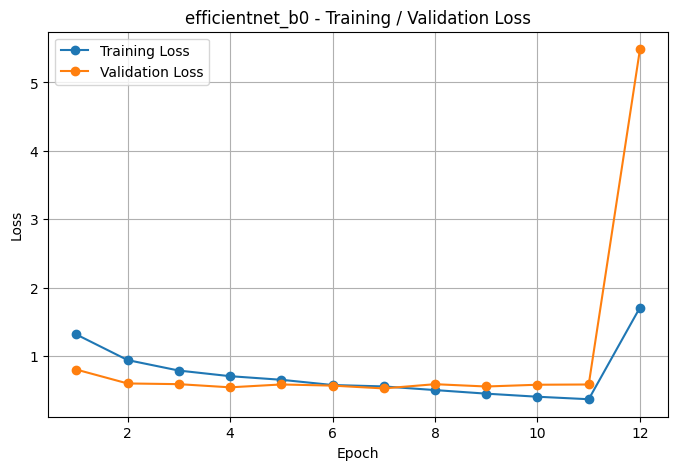


🛑 Early Stopping devreye girdi.
Validation loss iyileşmediği için eğitim erken durduruldu.

✅ Eğitim tamamlandı.
En iyi Validation Loss: 0.5302
En iyi model: checkpoints/efficientnet_b0_best_model.pth
Son checkpoint: checkpoints/efficientnet_b0_last_checkpoint.pth


In [50]:
efficientnet_model, eff_train_losses, eff_val_losses = train_model(
    model=efficientnet_model,
    model_name="efficientnet_b0",
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    device=device,
    num_epochs=15,
    learning_rate=1e-4,
    early_stopping_patience=4,
    resume=True
)

Model: efficientnet_b0_retry
Epoch: 2/15
Train Loss : 0.9520
Val Loss   : 0.8965
Val Accuracy: 0.7158
Learning Rate: 0.0001000
💾 Yeni en iyi model kaydedildi.


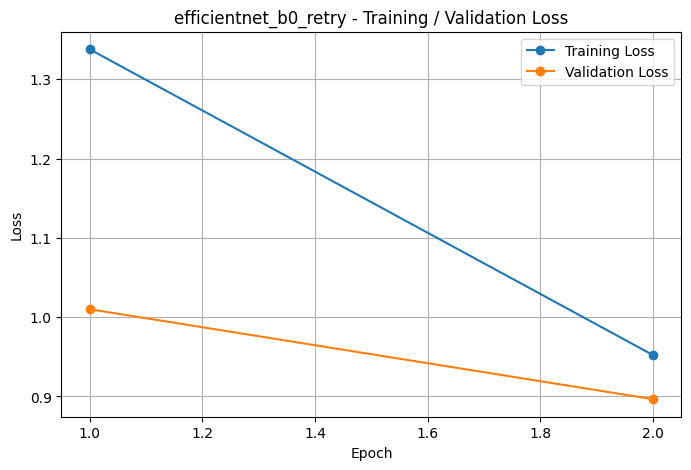

In [ ]:
efficientnet_model_retry, eff_retry_train_losses, eff_retry_val_losses = train_model(
    model=efficientnet_model,       # mevcut eğitilmiş modelden devam ediyor
    model_name="efficientnet_b0_retry",   # ← yeni isim, ayrı dosyalar
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    device=device,
    num_epochs=15,
    learning_rate=1e-4,
    early_stopping_patience=4,
    resume=False   # ← False kullan, çünkü "efficientnet_b0_retry" checkpoint'i henüz yok, zaten sıfırdan/mevcut haliyle başlayacak
)

Model: resnet50
Epoch: 11/15
Train Loss : 1.6305
Val Loss   : 1.6925
Val Accuracy: 0.4699
Learning Rate: 0.0000500
Early Stopping sayacı: 5/4


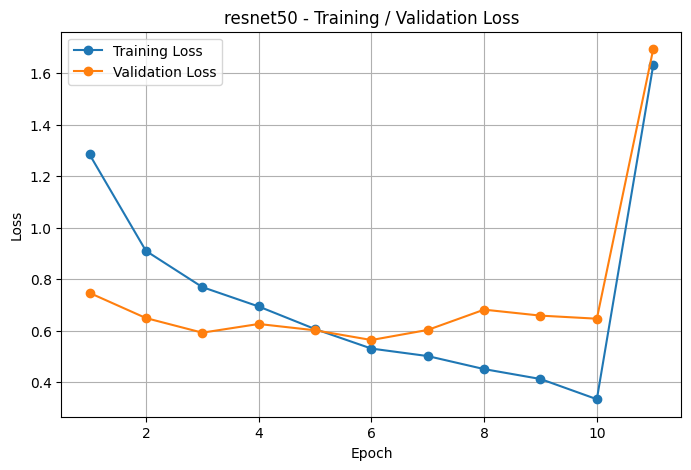


🛑 Early Stopping devreye girdi.
Validation loss iyileşmediği için eğitim erken durduruldu.

✅ Eğitim tamamlandı.
En iyi Validation Loss: 0.5634
En iyi model: checkpoints/resnet50_best_model.pth
Son checkpoint: checkpoints/resnet50_last_checkpoint.pth


In [51]:
resnet50_model, resnet_train_losses, resnet_val_losses = train_model(
    model=resnet50_model,
    model_name="resnet50",
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    device=device,
    num_epochs=15,
    learning_rate=1e-4,
    early_stopping_patience=4,
    resume=True
)

In [ ]:
resnet50_model_retry, res_retry_train_losses, res_retry_val_losses = train_model(
    model=resnet50_model,
    model_name="resnet50_retry",
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    device=device,
    num_epochs=15,
    learning_rate=1e-4,
    early_stopping_patience=4,
    resume=False
)

In [ ]:
# ==============================================================================
# DenseNet121 Eğitimi
# ==============================================================================
import torch.nn as nn
from torchvision.models import densenet121, DenseNet121_Weights

NUM_CLASSES = 5

densenet_model = densenet121(weights=DenseNet121_Weights.DEFAULT)
densenet_model.classifier = nn.Linear(densenet_model.classifier.in_features, NUM_CLASSES)
densenet_model = densenet_model.to(device)

print("✅ DenseNet121 hazır: çıktı sınıfı = 5")

densenet_model, dense_train_losses, dense_val_losses = train_model(
    model=densenet_model,
    model_name="densenet121",
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    device=device,
    num_epochs=15,
    learning_rate=1e-4,
    early_stopping_patience=4,
    resume=False,
)

In [ ]:
dense_metrics, dense_report = evaluate_full(densenet_model, val_loader, device)
print("=== DenseNet121 (Validation) ===")
for k, v in dense_metrics.items():
    print(f"{k}: {v:.4f}")
print(dense_report)

Model: baseline_cnn
Epoch: 15/15
Train Loss : 1.6093
Val Loss   : 1.6120
Val Accuracy: 0.4699
Learning Rate: 0.0000063
💾 Yeni en iyi model kaydedildi.


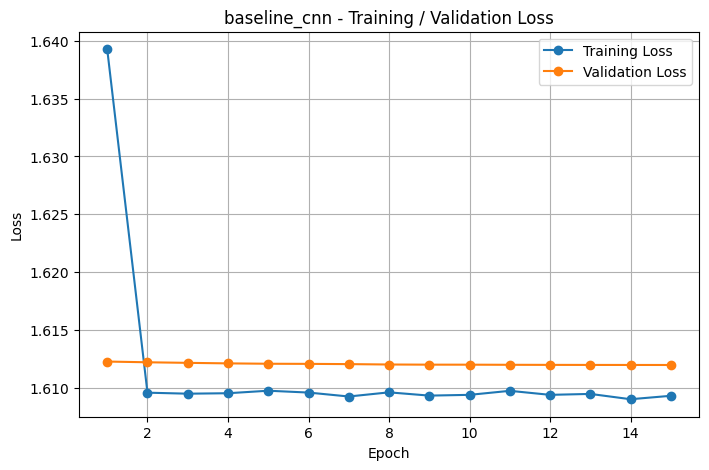


✅ Eğitim tamamlandı.
En iyi Validation Loss: 1.612
En iyi model: checkpoints/baseline_cnn_best_model.pth
Son checkpoint: checkpoints/baseline_cnn_last_checkpoint.pth


In [54]:
baseline_model = BaselineCNN(
    num_classes=5
).to(device)

baseline_model, baseline_train_losses, baseline_val_losses = train_model(
    model=baseline_model,
    model_name="baseline_cnn",
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    device=device,
    num_epochs=15,
    learning_rate=1e-4,
    early_stopping_patience=4,
    resume=False
)

In [25]:
import torch
import os

# ==============================================================================
# OTOMATİK ORTAM ALGILAMA — Checkpoint Klasörü
# ==============================================================================
try:
    import google.colab
    CHECKPOINT_DIR = "/content/drive/MyDrive/aptos2019/checkpoints"
    print("🚀 Google Colab ortamı algılandı.")
except ImportError:
    CHECKPOINT_DIR = "checkpoints"
    print("💻 Yerel Mac ortamı algılandı.")

print("Checkpoint klasörü:", CHECKPOINT_DIR)
print()

for name in ["efficientnet_b0", "resnet50"]:
    path = os.path.join(CHECKPOINT_DIR, f"{name}_last_checkpoint.pth")
    checkpoint = torch.load(path, map_location="cpu", weights_only=False)
    print(f"--- {name} ---")
    print("Kalınan epoch:", checkpoint.get("epoch"))
    print("En iyi val_loss:", checkpoint.get("best_val_loss"))
    print("Val loss geçmişi:", checkpoint.get("val_losses"))
    print("Early stop counter:", checkpoint.get("early_stop_counter"))
    print()

💻 Yerel Mac ortamı algılandı.
Checkpoint klasörü: checkpoints

--- efficientnet_b0 ---
Kalınan epoch: 11
En iyi val_loss: 0.5302155846780766
Val loss geçmişi: [0.805638941259332, 0.6028479057583002, 0.5926118828559834, 0.5461987328659641, 0.588086919054959, 0.5710949653484783, 0.5302155846780766, 0.5920705901143329, 0.5583957127534627, 0.5840893077557204, 0.5876442133728924, 5.486126589644802]
Early stop counter: 5

--- resnet50 ---
Kalınan epoch: 10
En iyi val_loss: 0.5633625352317518
Val loss geçmişi: [0.746220289032316, 0.6485860331462381, 0.5918317590254903, 0.6256040204418162, 0.6011071664388062, 0.5633625352317518, 0.6025341120573993, 0.6812765441957067, 0.6580753332930185, 0.6461166092118279, 1.692453346617235]
Early stop counter: 5



In [26]:
import torch
import os

# ==============================================================================
# OTOMATİK ORTAM ALGILAMA — Checkpoint Klasörü
# ==============================================================================
try:
    import google.colab
    CHECKPOINT_DIR = "/content/drive/MyDrive/aptos2019/checkpoints"
    print("🚀 Google Colab ortamı algılandı.")
except ImportError:
    CHECKPOINT_DIR = "checkpoints"
    print("💻 Yerel Mac ortamı algılandı.")

print("Checkpoint klasörü:", CHECKPOINT_DIR)
print()

path = os.path.join(CHECKPOINT_DIR, "baseline_cnn_last_checkpoint.pth")
checkpoint = torch.load(path, map_location="cpu", weights_only=False)

print("Kalınan epoch:", checkpoint.get("epoch"))
print("En iyi val_loss:", checkpoint.get("best_val_loss"))
print("Val loss geçmişi:", checkpoint.get("val_losses"))
print("Early stop counter:", checkpoint.get("early_stop_counter"))

💻 Yerel Mac ortamı algılandı.
Checkpoint klasörü: checkpoints

Kalınan epoch: 14
En iyi val_loss: 1.6119740543469705
Val loss geçmişi: [1.6122708652840285, 1.6122078296265316, 1.6121593342452754, 1.612113277768828, 1.6120814501913519, 1.612070707024121, 1.6120497066466535, 1.6120158043064055, 1.612002658062294, 1.6120006699379676, 1.6119905449653584, 1.6119836523233215, 1.6119794278848367, 1.6119766828140927, 1.6119740543469705]
Early stop counter: 0


In [27]:
def evaluate_model(model, test_loader, device):
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    accuracy = correct / total
    print(f"Test Doğruluğu (Accuracy): %{accuracy * 100:.2f}")
    return accuracy

### Başarı Metrikleri

In [28]:
import torch
import os
from torchvision.models import efficientnet_b0, resnet50
import torch.nn as nn
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    cohen_kappa_score, f1_score, classification_report
)

# BU KISIM EKLENECEK/DEĞİŞECEK:
try:
    import google.colab
    CHECKPOINT_DIR = "/content/drive/MyDrive/aptos2019/checkpoints"
    print("🚀 Google Colab ortamı algılandı.")
except ImportError:
    CHECKPOINT_DIR = "checkpoints"
    print("💻 Yerel Mac ortamı algılandı.")

NUM_CLASSES = 5

device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "mps" if torch.backends.mps.is_available()
    else "cpu"
)
print("Aktif Cihaz:", device)


def evaluate_full(model, dataloader, device):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())

    metrics = {
        "Accuracy": accuracy_score(all_labels, all_preds),
        "Macro Precision": precision_score(all_labels, all_preds, average="macro", zero_division=0),
        "Macro Recall": recall_score(all_labels, all_preds, average="macro", zero_division=0),
        "Macro F1": f1_score(all_labels, all_preds, average="macro", zero_division=0),
        "Weighted F1": f1_score(all_labels, all_preds, average="weighted", zero_division=0),
        "QWK": cohen_kappa_score(all_labels, all_preds, weights="quadratic"),
    }
    report = classification_report(all_labels, all_preds, zero_division=0)
    return metrics, report


# --- EfficientNet-B0 ---
eff_model = efficientnet_b0(weights=None)
eff_model.classifier[1] = nn.Linear(eff_model.classifier[1].in_features, NUM_CLASSES)
eff_state = torch.load(os.path.join(CHECKPOINT_DIR, "efficientnet_b0_best_model.pth"), map_location=device, weights_only=True)   # ← SENİN GÖSTERDİĞİN SATIR, DEĞİŞMEDİ
eff_model.load_state_dict(eff_state)
eff_model = eff_model.to(device)

eff_metrics, eff_report = evaluate_full(eff_model, val_loader, device)
print("=== EfficientNet-B0 (Validation) ===")
for k, v in eff_metrics.items():
    print(f"{k}: {v:.4f}")
print(eff_report)


# --- ResNet50 ---
res_model = resnet50(weights=None)
res_model.fc = nn.Linear(res_model.fc.in_features, NUM_CLASSES)
res_state = torch.load(os.path.join(CHECKPOINT_DIR, "resnet50_best_model.pth"), map_location=device, weights_only=True)
res_model.load_state_dict(res_state)
res_model = res_model.to(device)

res_metrics, res_report = evaluate_full(res_model, val_loader, device)
print("\n=== ResNet50 (Validation) ===")
for k, v in res_metrics.items():
    print(f"{k}: {v:.4f}")
print(res_report)

💻 Yerel Mac ortamı algılandı.
Aktif Cihaz: mps
=== EfficientNet-B0 (Validation) ===
Accuracy: 0.8033
Macro Precision: 0.6740
Macro Recall: 0.7168
Macro F1: 0.6842
Weighted F1: 0.8077
QWK: 0.8882
              precision    recall  f1-score   support

           0       0.98      0.99      0.99       172
           1       0.67      0.75      0.71        40
           2       0.79      0.60      0.68       104
           3       0.36      0.64      0.46        22
           4       0.57      0.61      0.59        28

    accuracy                           0.80       366
   macro avg       0.67      0.72      0.68       366
weighted avg       0.83      0.80      0.81       366


=== ResNet50 (Validation) ===
Accuracy: 0.7951
Macro Precision: 0.6658
Macro Recall: 0.7107
Macro F1: 0.6748
Weighted F1: 0.8037
QWK: 0.8900
              precision    recall  f1-score   support

           0       0.98      0.97      0.97       172
           1       0.58      0.78      0.67        40
           

# İleri Seviye Fine-Tuning — ResNet50 (QWK Odaklı, Kademeli)

## WeightedRandomSampler ile yeni train_loader

In [29]:
# ==============================================================================
# HÜCRE — WeightedRandomSampler ile Dengelenmiş train_loader
# ==============================================================================
import numpy as np
import torch
from torch.utils.data import DataLoader, WeightedRandomSampler

NUM_CLASSES = 5

class_sample_counts = df_train["diagnosis"].value_counts().reindex(range(NUM_CLASSES), fill_value=0).sort_index().values

sample_weights = np.array([
    1.0 / class_sample_counts[label] for label in df_train["diagnosis"].values
])
sample_weights = torch.from_numpy(sample_weights).double()

sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True,
)

train_dataset_balanced = APTOSDataset(
    df=df_train,
    folder_prefix=PATH_PREFIXES["train"],
    transform=train_transform,
)

train_loader_balanced = DataLoader(
    train_dataset_balanced,
    batch_size=32,
    sampler=sampler,        # shuffle=True ile birlikte KULLANILAMAZ
    num_workers=0,
)

print("✅ WeightedRandomSampler ile dengelenmiş train_loader_balanced hazır.")
print(f"Sınıf frekansları: {class_sample_counts}")

✅ WeightedRandomSampler ile dengelenmiş train_loader_balanced hazır.
Sınıf frekansları: [1434  300  808  154  234]


## Kademeli fine-tuning için ResNet50'yi hazırlama

In [30]:
# ==============================================================================
# HÜCRE — Mevcut ResNet50 Checkpoint'inden Devam + Kademeli Çözme Hazırlığı
# ==============================================================================
import os
import torch
import torch.nn as nn
from torchvision.models import resnet50, ResNet50_Weights

# ==============================================================================
# ORTAM TESPİTİ VE DİNAMİK CHECKPOINT DİZİNİ
# ==============================================================================
try:
    import google.colab
    DATA_DIR = "/content/drive/MyDrive/aptos2019"
    print("🚀 Google Colab ortamı algılandı.")
except ImportError:
    DATA_DIR = "aptos2019"
    print("💻 Yerel Mac ortamı algılandı.")

CHECKPOINT_DIR = "checkpoints"
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

NUM_CLASSES = 5

device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "mps" if torch.backends.mps.is_available()
    else "cpu"
)
print("Aktif Cihaz:", device)

# 1. Mimariyi kur
resnet50_finetune = resnet50(weights=ResNet50_Weights.DEFAULT)
resnet50_finetune.fc = nn.Linear(resnet50_finetune.fc.in_features, NUM_CLASSES)

# 2. Zaten eğitilmiş ağırlıkları yükle (val_loss 0.7832 olan checkpoint)

model_path = os.path.abspath(os.path.join(CHECKPOINT_DIR, "resnet50_best_model.pth"))

state_dict = torch.load(
    model_path,
    map_location=device,
    weights_only=True,
)
resnet50_finetune.load_state_dict(state_dict)
resnet50_finetune = resnet50_finetune.to(device)

print("✅ Mevcut ResNet50 ağırlıkları yüklendi, fine-tuning için hazır.")

# 3. Kademeli çözme fonksiyonu — istediğimiz katmanı serbest bırakır, gerisi donuk kalır
def set_trainable_layers(model, unfreeze_from="layer4"):
    """
    unfreeze_from seçenekleri (ResNet50 katman sırası):
    'none'   -> hiçbir şey açma, sadece fc eğitilebilir
    'layer4' -> son blok + fc eğitilebilir (önerilen ilk adım)
    'layer3' -> layer3 + layer4 + fc eğitilebilir
    'all'    -> tüm gövde eğitilebilir (dikkatli learning rate ile)
    """
    layer_order = ["conv1", "bn1", "layer1", "layer2", "layer3", "layer4", "fc"]

    if unfreeze_from == "none":
        unfreeze_idx = len(layer_order) - 1  # sadece fc
    elif unfreeze_from == "all":
        unfreeze_idx = 0
    else:
        unfreeze_idx = layer_order.index(unfreeze_from)

    for name, param in model.named_parameters():
        top_level = name.split(".")[0]
        layer_idx = layer_order.index(top_level) if top_level in layer_order else len(layer_order)
        param.requires_grad = layer_idx >= unfreeze_idx

    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total = sum(p.numel() for p in model.parameters())
    print(f"Eğitilebilir parametre: {trainable:,} / {total:,} ({100*trainable/total:.1f}%)")


# İlk aşama: sadece son blok (layer4) + fc açık, gövdenin geri kalanı donuk
set_trainable_layers(resnet50_finetune, unfreeze_from="layer4")

💻 Yerel Mac ortamı algılandı.
Aktif Cihaz: mps
✅ Mevcut ResNet50 ağırlıkları yüklendi, fine-tuning için hazır.
Eğitilebilir parametre: 14,974,981 / 23,518,277 (63.7%)


## QWK-odaklı, discriminative LR'li gelişmiş train_model fonksiyonu

In [31]:
# ==============================================================================
# HÜCRE — Gelişmiş train_model_advanced(): QWK-odaklı, Discriminative LR,
#          Cosine Annealing + Warmup, Mixed Precision (AMP)
# ==============================================================================
import os
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR, LinearLR, SequentialLR
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    cohen_kappa_score, f1_score,
)
from IPython.display import clear_output


def build_discriminative_optimizer(model, head_lr=1e-3, backbone_lr=1e-5, weight_decay=1e-4):
    """
    fc katmanına (head) yüksek LR, gövdeye (backbone, eğer açıksa) düşük LR verir.
    Böylece zaten öğrenilmiş özellikler bozulmadan, yeni katman hızlı öğrenir.
    """
    head_params = []
    backbone_params = []

    for name, param in model.named_parameters():
        if not param.requires_grad:
            continue
        if name.startswith("fc"):
            head_params.append(param)
        else:
            backbone_params.append(param)

    param_groups = [{"params": head_params, "lr": head_lr}]
    if backbone_params:
        param_groups.append({"params": backbone_params, "lr": backbone_lr})

    return AdamW(param_groups, weight_decay=weight_decay)


def train_model_advanced(
    model,
    model_name,
    train_loader,
    val_loader,
    criterion,
    device,
    num_epochs=15,
    head_lr=1e-3,
    backbone_lr=1e-5,
    warmup_epochs=1,
    early_stopping_patience=5,
    checkpoint_dir="./checkpoints",
    use_amp=True,
):
    os.makedirs(checkpoint_dir, exist_ok=True)
    best_model_path = os.path.join(checkpoint_dir, f"{model_name}_best_qwk.pth")
    checkpoint_path = os.path.join(checkpoint_dir, f"{model_name}_finetune_checkpoint.pth")

    optimizer = build_discriminative_optimizer(model, head_lr=head_lr, backbone_lr=backbone_lr)

    # Warmup (LinearLR) + Cosine Annealing zinciri
    warmup_steps = warmup_epochs
    scheduler_warmup = LinearLR(optimizer, start_factor=0.1, total_iters=warmup_steps)
    scheduler_cosine = CosineAnnealingLR(optimizer, T_max=max(num_epochs - warmup_steps, 1))
    scheduler = SequentialLR(optimizer, schedulers=[scheduler_warmup, scheduler_cosine], milestones=[warmup_steps])

    scaler = torch.cuda.amp.GradScaler(enabled=(use_amp and device.type == "cuda"))

    train_losses, val_losses, val_qwks = [], [], []
    best_qwk = -1.0
    early_stop_counter = 0

    for epoch in range(num_epochs):
        # ---------------- TRAIN ----------------
        model.train()
        running_train_loss = 0.0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()

            with torch.autocast(device_type=device.type, enabled=(use_amp and device.type == "cuda")):
                outputs = model(images)
                loss = criterion(outputs, labels)

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            running_train_loss += loss.item() * images.size(0)

        train_loss = running_train_loss / len(train_loader.dataset)

        # ---------------- VALIDATION ----------------
        model.eval()
        running_val_loss = 0.0
        all_preds, all_labels = [], []

        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                running_val_loss += loss.item() * images.size(0)

                preds = torch.argmax(outputs, dim=1)
                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())

        val_loss = running_val_loss / len(val_loader.dataset)
        val_acc = accuracy_score(all_labels, all_preds)
        val_qwk = cohen_kappa_score(all_labels, all_preds, weights="quadratic")
        val_f1 = f1_score(all_labels, all_preds, average="macro", zero_division=0)

        train_losses.append(train_loss)
        val_losses.append(val_loss)
        val_qwks.append(val_qwk)

        scheduler.step()
        current_lrs = [g["lr"] for g in optimizer.param_groups]

        # ---------------- EN İYİ MODEL: QWK'YA GÖRE ----------------
        if val_qwk > best_qwk:
            best_qwk = val_qwk
            early_stop_counter = 0
            torch.save(model.state_dict(), best_model_path)
            status = "💾 Yeni en iyi model (QWK'ya göre) kaydedildi."
        else:
            early_stop_counter += 1
            status = f"Early Stopping sayacı: {early_stop_counter}/{early_stopping_patience}"

        torch.save({
            "epoch": epoch,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "best_qwk": best_qwk,
            "train_losses": train_losses,
            "val_losses": val_losses,
            "val_qwks": val_qwks,
            "early_stop_counter": early_stop_counter,
        }, checkpoint_path)

        clear_output(wait=True)
        print(f"Model: {model_name} | Epoch: {epoch + 1}/{num_epochs}")
        print(f"Train Loss : {train_loss:.4f}")
        print(f"Val Loss   : {val_loss:.4f}")
        print(f"Val Accuracy: {val_acc:.4f}")
        print(f"Val Macro F1: {val_f1:.4f}")
        print(f"Val QWK    : {val_qwk:.4f}  (En iyi: {best_qwk:.4f})")
        print(f"LR'ler     : {current_lrs}")
        print(status)

        plt.figure(figsize=(12, 4))
        plt.subplot(1, 2, 1)
        plt.plot(train_losses, marker="o", label="Train Loss")
        plt.plot(val_losses, marker="o", label="Val Loss")
        plt.legend(); plt.grid(); plt.title(f"{model_name} - Loss")

        plt.subplot(1, 2, 2)
        plt.plot(val_qwks, marker="o", color="green", label="Val QWK")
        plt.legend(); plt.grid(); plt.title(f"{model_name} - QWK")
        plt.tight_layout()
        plt.show()

        if early_stop_counter >= early_stopping_patience:
            print("\n🛑 Early Stopping devreye girdi.")
            break

    model.load_state_dict(torch.load(best_model_path, map_location=device, weights_only=True))
    print(f"\n✅ Fine-tuning tamamlandı. En iyi QWK: {best_qwk:.4f}")
    print(f"En iyi model: {best_model_path}")

    return model, train_losses, val_losses, val_qwks

## Kademeli eğitim çağrıları (2 aşamalı fine-tuning)

Model: resnet50_stage2_layer3 | Epoch: 5/10
Train Loss : 0.1388
Val Loss   : 0.6933
Val Accuracy: 0.8579
Val Macro F1: 0.7536
Val QWK    : 0.9074  (En iyi: 0.9126)
LR'ler     : [0.00029341204441673266, 5.8682408883346535e-06]
Early Stopping sayacı: 4/4


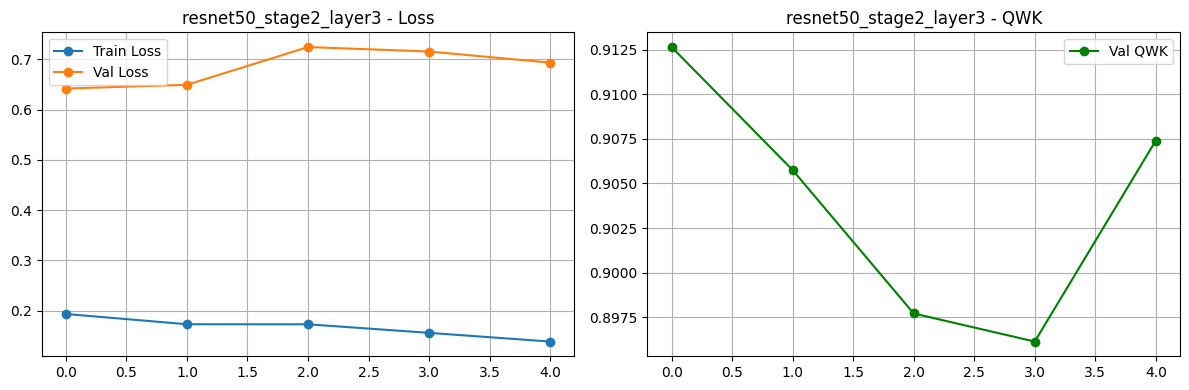


🛑 Early Stopping devreye girdi.

✅ Fine-tuning tamamlandı. En iyi QWK: 0.9126
En iyi model: checkpoints/resnet50_stage2_layer3_best_qwk.pth

🏁 Tüm fine-tuning aşamaları tamamlandı.
Aşama 1 en iyi QWK: 0.9055
Aşama 2 en iyi QWK: 0.9126


In [102]:
# ==============================================================================
# HÜCRE — 2 AŞAMALI KADEMELİ FİNE-TUNING
# ==============================================================================
import os
criterion = nn.CrossEntropyLoss()

# Ortama göre checkpoint dizinini otomatik belirle
try:
    import google.colab
    CHECKPOINT_DIR_DRIVE = "/content/drive/MyDrive/aptos2019/checkpoints"
except ImportError:
    CHECKPOINT_DIR_DRIVE = "checkpoints"

os.makedirs(CHECKPOINT_DIR_DRIVE, exist_ok=True)

print("=" * 60)
print("AŞAMA 1: layer4 + fc fine-tuning")
print("=" * 60)

resnet50_finetune, stage1_train_losses, stage1_val_losses, stage1_qwks = train_model_advanced(
    model=resnet50_finetune,
    model_name="resnet50_stage1_layer4",
    train_loader=train_loader_balanced,   # WeightedRandomSampler'lı loader
    val_loader=val_loader,
    criterion=criterion,                   # mevcut weighted CrossEntropyLoss
    device=device,
    num_epochs=10,
    head_lr=1e-3,
    backbone_lr=1e-4,   # layer4 açık olduğu için ona da makul bir LR
    warmup_epochs=1,
    early_stopping_patience=4,
    checkpoint_dir=CHECKPOINT_DIR_DRIVE,
    use_amp=True,
)




# ==============================================================================
# AŞAMA 2: layer3 + layer4 + fc açık, çok daha düşük LR ile derin fine-tuning
# ==============================================================================
print("\n" + "=" * 60)
print("AŞAMA 2: layer3 + layer4 + fc fine-tuning (daha derin, daha düşük LR)")
print("=" * 60)

set_trainable_layers(resnet50_finetune, unfreeze_from="layer3")

resnet50_finetune, stage2_train_losses, stage2_val_losses, stage2_qwks = train_model_advanced(
    model=resnet50_finetune,
    model_name="resnet50_stage2_layer3",
    train_loader=train_loader_balanced,
    val_loader=val_loader,
    criterion=criterion,
    device=device,
    num_epochs=10,
    head_lr=5e-4,        # aşama 1'e göre biraz daha düşük
    backbone_lr=1e-5,    # gövde için çok düşük, ImageNet bilgisini korumak için
    warmup_epochs=1,
    early_stopping_patience=4,
    checkpoint_dir=CHECKPOINT_DIR_DRIVE,
    use_amp=True,
)

print("\n🏁 Tüm fine-tuning aşamaları tamamlandı.")
print(f"Aşama 1 en iyi QWK: {max(stage1_qwks):.4f}")
print(f"Aşama 2 en iyi QWK: {max(stage2_qwks):.4f}")

## Test-Time Augmentation (TTA) ile nihai değerlendirme

In [37]:
# ==============================================================================
# HÜCRE — Test-Time Augmentation (TTA) ile Nihai Değerlendirme (TEMİZ YÜKLEME)
# ==============================================================================
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision.models import resnet50
from sklearn.metrics import (
    accuracy_score, cohen_kappa_score, f1_score, classification_report
)

NUM_CLASSES = 5


def evaluate_with_tta(model, dataloader, device, n_tta=4):
    model.eval()
    all_preds, all_labels = [], []

    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            batch_probs = torch.zeros(images.size(0), 5, device=device)

            for tta_idx in range(n_tta):
                if tta_idx == 0:
                    aug_images = images
                elif tta_idx == 1:
                    aug_images = torch.flip(images, dims=[3])
                elif tta_idx == 2:
                    aug_images = torch.flip(images, dims=[2])
                elif tta_idx == 3:
                    aug_images = torch.rot90(images, k=2, dims=[2, 3])
                else:
                    aug_images = images

                outputs = model(aug_images)
                probs = F.softmax(outputs, dim=1)
                batch_probs += probs

            batch_probs /= n_tta
            preds = torch.argmax(batch_probs, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())

    metrics = {
        "Accuracy": accuracy_score(all_labels, all_preds),
        "QWK": cohen_kappa_score(all_labels, all_preds, weights="quadratic"),
        "Macro F1": f1_score(all_labels, all_preds, average="macro", zero_division=0),
        "Weighted F1": f1_score(all_labels, all_preds, average="weighted", zero_division=0),
    }
    report = classification_report(all_labels, all_preds, zero_division=0)
    return metrics, report


# ---- Fine-tune edilmiş modeli DOSYADAN temiz yükle ----
resnet50_finetune_clean = resnet50(weights=None)
resnet50_finetune_clean.fc = nn.Linear(resnet50_finetune_clean.fc.in_features, NUM_CLASSES)
state = torch.load("checkpoints/resnet50_stage2_layer3_best_qwk.pth", map_location=device, weights_only=True)
resnet50_finetune_clean.load_state_dict(state)
resnet50_finetune_clean = resnet50_finetune_clean.to(device)
resnet50_finetune_clean.eval()

print("=== ResNet50 Fine-tuned (temiz yüklendi, TTA) — TEST SETİ ===")
tta_metrics, tta_report = evaluate_with_tta(resnet50_finetune_clean, test_loader, device, n_tta=4)
for k, v in tta_metrics.items():
    print(f"{k}: {v:.4f}")
print(tta_report)

=== ResNet50 Fine-tuned (temiz yüklendi, TTA) — TEST SETİ ===
Accuracy: 0.8224
QWK: 0.8833
Macro F1: 0.5982
Weighted F1: 0.8125
              precision    recall  f1-score   support

           0       0.98      0.98      0.98       199
           1       0.61      0.57      0.59        30
           2       0.68      0.85      0.76        87
           3       0.27      0.18      0.21        17
           4       0.60      0.36      0.45        33

    accuracy                           0.82       366
   macro avg       0.63      0.59      0.60       366
weighted avg       0.81      0.82      0.81       366



## Grad-CAM

In [ ]:
# ============================================================
# GRAD-CAM KÜTÜPHANESİNİ KUR
# ============================================================

!pip install -q grad-cam

from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image

print("✅ pytorch-grad-cam hazır.")

In [ ]:
# ============================================================
# GRAD-CAM FONKSİYONU
# ResNet50'nin son convolution bloğunu kullanır
# ============================================================

import torch
import numpy as np


def generate_gradcam(
    model,
    input_tensor,
    target_class=None
):

    model.eval()

    # ResNet50'nin son convolution bloğu
    target_layers = [
        model.layer4[-1]
    ]

    # Sınıf verilmezse modelin kendi tahminini kullan
    if target_class is None:

        with torch.inference_mode():

            outputs = model(
                input_tensor
            )

            target_class = torch.argmax(
                outputs,
                dim=1
            ).item()


    targets = [
        ClassifierOutputTarget(
            target_class
        )
    ]


    # Grad-CAM oluştur
    with GradCAM(
        model=model,
        target_layers=target_layers
    ) as cam:

        grayscale_cam = cam(
            input_tensor=input_tensor,
            targets=targets
        )


    # Batch'in ilk görüntüsü
    grayscale_cam = grayscale_cam[0]


    return (
        grayscale_cam,
        target_class
    )


print("✅ Grad-CAM fonksiyonu hazır.")

In [ ]:
# ============================================================
# ORİJİNAL + CLAHE + GRAD-CAM GÖRSELLEŞTİRME
# ============================================================

import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image
from pytorch_grad_cam.utils.image import show_cam_on_image


# ============================================================
# 1. VALIDATION SETİNDEN BİR ÖRNEK SEÇ
# ============================================================

sample_index = 0

row = df_valid.iloc[
    sample_index
]


# Dosya adını bul
if (
    "image_file" in row
    and pd.notnull(row["image_file"])
):

    image_file = os.path.basename(
        str(row["image_file"])
    )

else:

    image_file = (
        f"{row['id_code']}.png"
    )


image_path = os.path.join(
    VALID_IMAGE_DIR,
    image_file
)


print(
    "Görüntü:",
    image_path
)


# ============================================================
# 2. ORİJİNAL GÖRÜNTÜ
# ============================================================

with Image.open(image_path) as img:

    original_image = np.array(
        img.convert("RGB")
    )


# ============================================================
# 3. AUTO-CROP
# ============================================================

cropped_image = auto_crop(
    original_image,
    threshold=10,
    padding=5
)


# ============================================================
# 4. CLAHE
# ============================================================

clahe_image = apply_clahe(
    cropped_image
)


# ============================================================
# 5. MODEL INPUT
# Aynı validation transform uygulanır
# ============================================================

transformed = val_transform(
    image=clahe_image
)

input_tensor = (
    transformed["image"]
    .unsqueeze(0)
    .to(device)
)


# ============================================================
# 6. GRAD-CAM
# ============================================================

grayscale_cam, predicted_class = (
    generate_gradcam(
        model=resnet50_finetune,
        input_tensor=input_tensor
    )
)


# ============================================================
# 7. HEATMAP İÇİN GÖRÜNTÜYÜ 224x224 YAP
# ============================================================

visual_image = cv2.resize(
    clahe_image,
    (224, 224)
)


visual_image_float = (
    visual_image.astype(
        np.float32
    )
    / 255.0
)


gradcam_image = show_cam_on_image(
    visual_image_float,
    grayscale_cam,
    use_rgb=True
)


# ============================================================
# 8. SINIF İSİMLERİ
# ============================================================

class_names = {
    0: "No DR",
    1: "Mild",
    2: "Moderate",
    3: "Severe",
    4: "Proliferative DR"
}


true_class = int(
    row["diagnosis"]
)


# ============================================================
# 9. GÖRSELLEŞTİR
# ============================================================

plt.figure(
    figsize=(15, 5)
)


plt.subplot(
    1,
    3,
    1
)

plt.imshow(
    original_image
)

plt.title(
    "Orijinal Görüntü"
)

plt.axis(
    "off"
)


plt.subplot(
    1,
    3,
    2
)

plt.imshow(
    clahe_image
)

plt.title(
    "Auto-Crop + CLAHE"
)

plt.axis(
    "off"
)


plt.subplot(
    1,
    3,
    3
)

plt.imshow(
    gradcam_image
)

plt.title(
    f"Grad-CAM\n"
    f"Gerçek: {class_names[true_class]} | "
    f"Tahmin: {class_names[predicted_class]}"
)

plt.axis(
    "off"
)


plt.tight_layout()

plt.show()


print(
    "Gerçek sınıf :",
    class_names[true_class]
)

print(
    "Tahmin edilen:",
    class_names[predicted_class]
)